# Lecture 7: Probability and Statistical Distributions

One of the key research tools used by social scientists (and data scientists!) is **statistical analysis**. 

We have already introduced you to some fundamental building blocks of statistics, such as measures of central tendency (mean, median, and mode). Over the next few weeks, we are going to show how statistical tools can be used to ask and answer questions!

## Probability

A **probability** tells us the **likelihood that a particular outcome will occur**. 

For example, let's say that we flip a coin. 

For any given coin flip, how likely are we to get "Heads" and how likely are we to get "Tails"?

We can *simulate* this process in python, using the pandas library. Let's create a pandas Series called `coin_flip`, which contains the values "Heads" and "Tails".

In [35]:
import pandas as pd

coin_flip = pd.Series(["Heads", "Tails"])

coin_flip

0    Heads
1    Tails
dtype: object

pandas contains a function `sample`, which **randomly** selects one of the options from a Series. Each time we run this function, there is an equal chance that it will produce "Heads" or "Tails".

In [36]:
coin_flip.sample()

0    Heads
dtype: object

If we want to get consistent outcomes every time, we can include the argument `random_state` and choose a number to assign it. This allows us to replicate our results later!

In [37]:
coin_flip.sample(random_state = 1)

0    Heads
dtype: object

We can also use `sample` to simulate multiple coin flips in a row! For example, let's say we wanted to flip the coin 10 times (`n = 10`). 

- We also need to tell this function to `replace` the options each time. If `replace = False`, it will remove any options that have already been sampled. For example, once our coin has flipped "Heads", it would remove "Heads" from the list of options.

In [38]:
flips10 = coin_flip.sample(n = 10, replace = True, random_state = 1)

flips10

1    Tails
1    Tails
0    Heads
0    Heads
1    Tails
1    Tails
1    Tails
1    Tails
1    Tails
0    Heads
dtype: object

We can use `.value_counts()` to determine *how many times* each outcome occurred:

In [39]:
flips10_frequency = flips10.value_counts()

flips10_frequency

Tails    7
Heads    3
Name: count, dtype: int64

Let's plot these values using `plot.bar()`!

<Axes: >

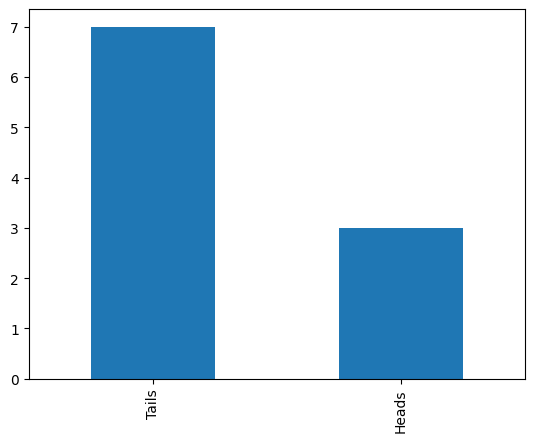

In [40]:
flips10_frequency.plot.bar()

In statistics, we tend to think about these things in terms of **probabilities** instead of **counts**.

- Rather than counting up the number of outcomes, we want to know the *percentage* of the time that each outcome occurs!

- Probabilities therefore can range between **0** (0%) and **1** (100%).


To find the probability in this case, we can divide the **frequency** of each outcome by the **number** of "trials" (coin flips):

In [41]:
flips10_probability = flips10_frequency/len(flips10)

flips10_probability

Tails    0.7
Heads    0.3
Name: count, dtype: float64

Then, we can use `plot.bar()` to create a **frequency plot**:

<Axes: >

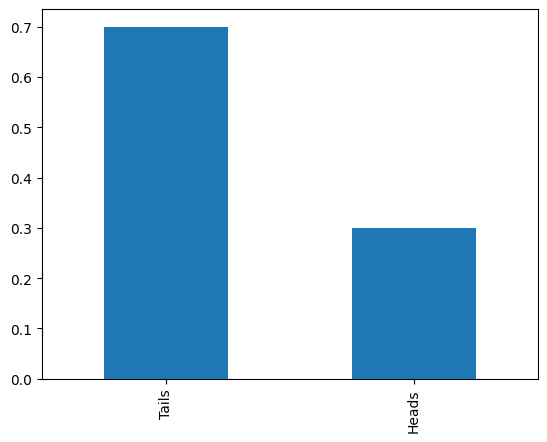

In [42]:
flips10_probability.plot.bar()

We can also easily simulate what this looks like for larger samples. For example, what if we flip the coin **10,000** times?

<Axes: >

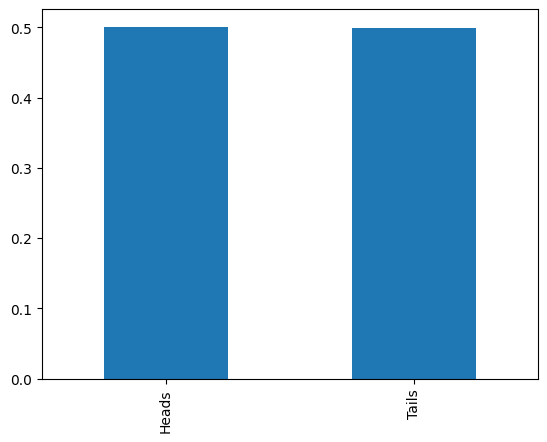

In [43]:
flips10k = coin_flip.sample(n = 10000, replace = True, random_state = 1)

flips10k_frequency = flips10k.value_counts()

flips10k_probability = flips10k_frequency/len(flips10k)

flips10k_probability.plot.bar()

A fundamental property of statistics is the **Law of Large Numbers**: as the number of observations you have increases, you tend to get closer and closer to representing the "true" probability associated with each outcome. 

- With 10,000 observations, we are probably going to be closer to the *true* probability of flipping "Heads" or "Tails" (0.5, aka 50%) than we were with only 10 flips!

## Statistical Distributions

A **statistical distribution** is a mathematical/graphical representation of the probability associated with each outcome.

![no_zeros.png](no_zeros.png)

### Bernoulli Distribution

Graphing the probability associated with flipping "Heads" or "Tails" in a given coin flip is a particular type of statistical distribution known as a **Bernoulli Distribution**!

- The probability of getting "Heads" is: 

    $p = 0.5$

- The probability of getting "Tails" is: 

    $(1 - p) = 0.5$

### Binomial Distribution

While a **Bernoulli Distribution** looks at a single coin flip (also known as a "trial"), a **Binomial Distribution** looks at how likely it is that we "succeed" in a particular number of trials.

- For example, if we flipped a coin 10 times, how likely is it that **exactly 3 of those 10 flips** will result in "Heads"?

- To figure this out, we need to try flipping the coin 10 times, and then do that *a bunch of times in a row*!

We can run a bunch of simulations in a row with a `for` loop. The *number of times* we run through the `for` loop can be set using the function `range()`.

In [44]:
for i in range(5):
    print(i)

0
1
2
3
4


Let's say we want to see how many coin flips out of 10 come up "Heads", but we want to test this **1,000** times! 

In [45]:
results = []

for i in range(1000):
    flips10 = coin_flip.sample(n = 10, replace = True, random_state = i)
    n_heads = (flips10 == "Heads").sum()
    results.append(n_heads)

results = pd.Series(results)

results

0      2
1      3
2      5
3      5
4      5
      ..
995    4
996    3
997    6
998    4
999    3
Length: 1000, dtype: int64

We can plot the distribution of our results by constructing a **frequency plot** (`plot.bar`), which shows the frequency associated with each discrete value.

- `.value_counts()` counts up the number of times each value appears in our results

- `.sort_index()` rearranges this count in order of value (0 heads, 1 head, 2 heads, etc.)

In [46]:
results_count = results.value_counts()

results_count

5    244
6    225
4    210
7    114
3    104
8     41
2     36
1     14
9     11
0      1
Name: count, dtype: int64

In [47]:
results_count_sorted = results_count.sort_index()

results_count_sorted

0      1
1     14
2     36
3    104
4    210
5    244
6    225
7    114
8     41
9     11
Name: count, dtype: int64

<Axes: >

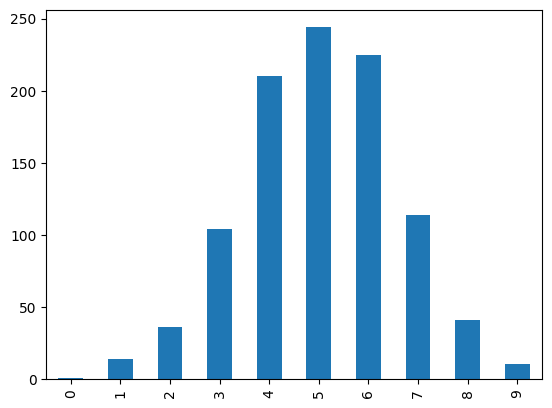

In [48]:
results_count_sorted.plot.bar()

Each bar of our frequency plot represents the number of times (out of 10) that we flipped heads.

- In our 1,000 simulations of flipping a coin 10 times, we got exactly 3 heads roughly 100 times (10% of the time)

- Less common scenarios (such as only getting 1 head) can happen too!

Even though each coin flip is 50/50, this reflects the uncertainty of what might **actually** happen!

Let's change this plot to show **probability** instead of frequency, by dividing `results_count_sorted` by the total number of trials

<Axes: >

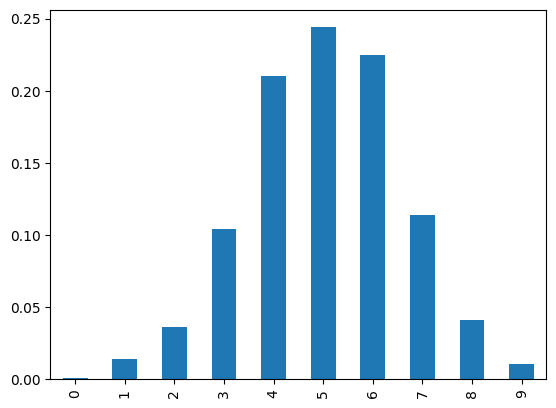

In [49]:
results_prob_sorted = results_count_sorted/sum(results_count_sorted)

results_prob_sorted.plot.bar()

While 5 heads in 10 flips is the most likely outcome, it only happens about 25% of the time.

It's always a good idea to include a descriptive title and axis labels on our plots. We can do this using functions from the `matplotlib.pyplot` library.

Text(0.5, 1.0, 'Probability of Flipping Heads in 10 Trials')

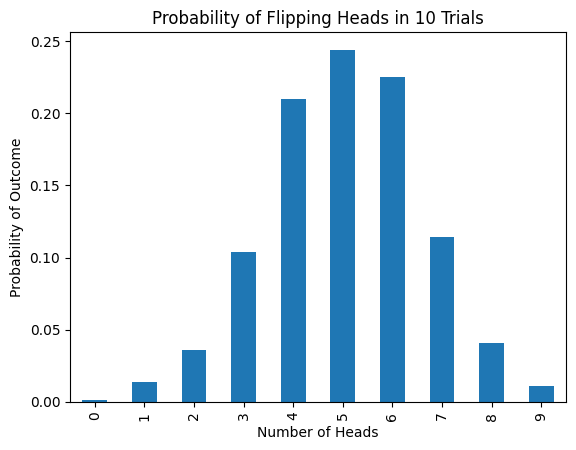

In [66]:
import matplotlib.pyplot as plt

results_prob_sorted.plot.bar()

plt.xlabel("Number of Heads")

plt.ylabel("Probability of Outcome")

plt.title("Probability of Flipping Heads in 10 Trials")

## Continuous Distributions

Coin flips provide a simple example with a binary outcome. Statistical distributions also exist for continuous numbers, where there are essentially *infinite* possible outcomes!

Let's take a look at some real-life data: maximum daily temperatures in Toronto in 2024.

In [50]:
climate_data = pd.read_csv("en_climate_daily_ON_6158731_2024_P1D.csv")

climate_data.head()

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-79.63,43.68,TORONTO INTL A,6158731,2024-01-01,2024,1,1,NaN,-1.4,...,0.4,NaN,0.2,NaN,2.0,NaN,32.0,NaN,31.0,NaN
1,-79.63,43.68,TORONTO INTL A,6158731,2024-01-02,2024,1,2,NaN,0.6,...,0.0,NaN,0.0,NaN,NaN,NaN,25.0,NaN,40.0,NaN
2,-79.63,43.68,TORONTO INTL A,6158731,2024-01-03,2024,1,3,NaN,2.4,...,0.0,T,0.0,T,0.0,T,26.0,NaN,37.0,NaN
3,-79.63,43.68,TORONTO INTL A,6158731,2024-01-04,2024,1,4,NaN,0.8,...,0.0,T,0.0,T,NaN,NaN,33.0,NaN,53.0,NaN
4,-79.63,43.68,TORONTO INTL A,6158731,2024-01-05,2024,1,5,NaN,-0.7,...,0.0,NaN,0.0,NaN,NaN,NaN,24.0,NaN,35.0,NaN


This data contains details about the daily weather at Toronto International Airport for each day in 2024. 

Let's look at just the maximum daily temperatures

In [51]:
max_temps = climate_data["Max Temp (C)"]

max_temps.head()

0   -1.4
1    0.6
2    2.4
3    0.8
4   -0.7
Name: Max Temp (C), dtype: float64

Whereas we used a **frequency plot** (`plot.bar()`) for discrete data (such as the number of coin flips), we will use a **histogram** `plot.hist()` to look at the statistical distribution of continuous data like temperature.

<Axes: ylabel='Frequency'>

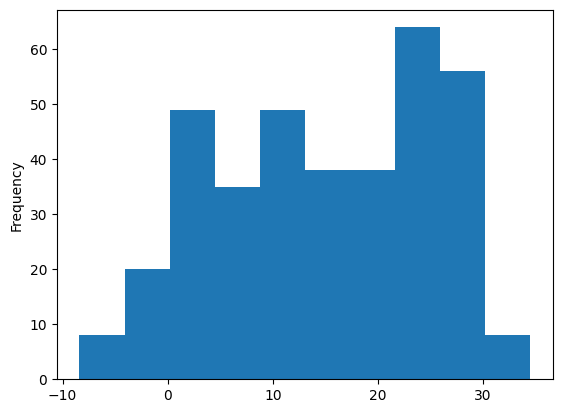

In [52]:
max_temps.plot.hist()

To make this plot easier to look at, we'll also add two arguments:

- `edgecolor = "black"`

- `bins =` the boundaries around each of the bins we want to include

<Axes: ylabel='Frequency'>

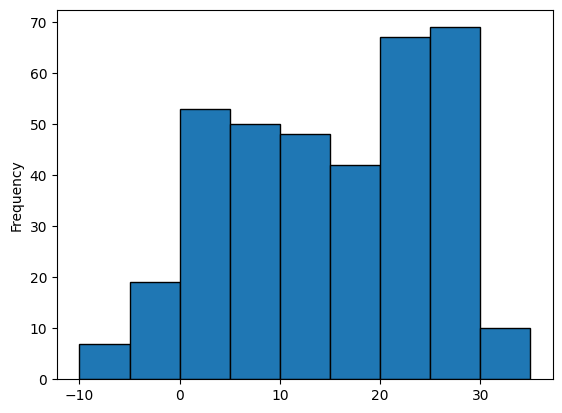

In [53]:
max_temps.plot.hist(edgecolor = "black", bins = [-10, -5, 0, 5, 10, 15, 20, 25, 30, 35])

# max_temps.plot.hist(edgecolor = "black", bins = range(-10, 40, 5)) ## Second number is the upper bound; not included

<Axes: ylabel='Frequency'>

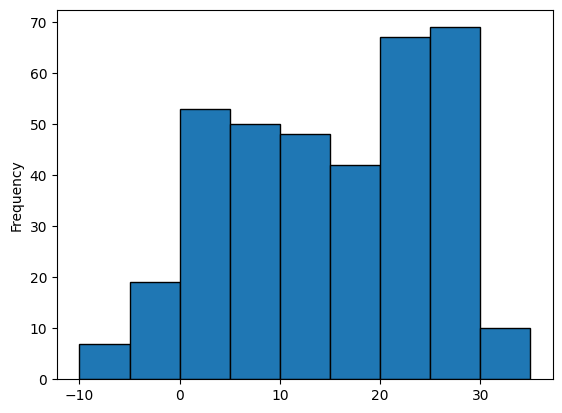

In [ ]:
max_temps.plot.hist(edgecolor = "black", bins = range(-10, 40, 5))

plt.xlabel("Maximum Daily Temperature")

plt.ylabel("Number of Days")

plt.title("Maximum Daily Temperature in Toronto in 2024")

As with the coin flips, this shows the number of times that a particular outcome occurs. This time, however, it shows frequencies for ranges (or "bins") of values. 

For example:

- There were 10 days where the high temperature was **30+ degrees** (looking at the frequency for the right-most bar)

- There were 7 days where the high temperature was **below -5 degrees** (looking at the frequency for the left-most bar)

Converting this into a **probability** distribution is a bit less straightforward, but we can use the function `histplot` from the `seaborn` library to accomplish this.

Text(0.5, 1.0, 'Maximum Daily Temperature in Toronto in 2024')

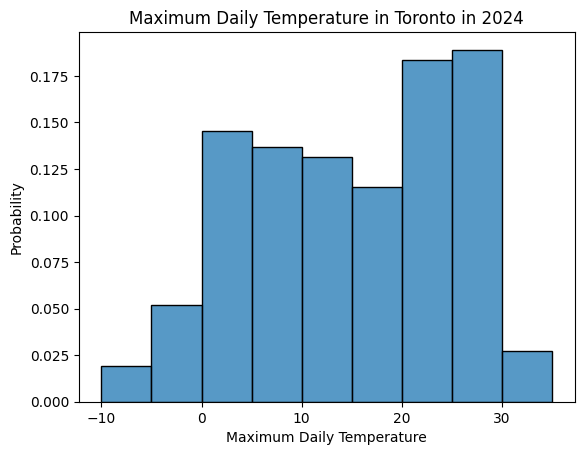

In [67]:
import seaborn as sns

sns.histplot(max_temps, bins = range(-10, 40, 5), stat="probability")

plt.xlabel("Maximum Daily Temperature")

plt.ylabel("Probability")

plt.title("Maximum Daily Temperature in Toronto in 2024")

Each of these bars now shows the probability that a randomly selected day from 2025 would fall within a specific temperature range.

- For example, we can see the probability that the maximum temperature of a randomly selected day from 2025 would greater than ~30 degrees: **0.025, or 2.5%**!

We can randomly select a daily high temperature using `sample`:

In [56]:
max_temps.sample(n = 1)

155    26.8
Name: Max Temp (C), dtype: float64

We can also select **multiple** days at once, using `replace = False` so we don't select the same day twice in one sample! This will be valuable for constructing data samples next week.

In [57]:
max_temps.sample(n = 10, replace = False)

309    24.3
28      3.9
72     20.6
165    24.0
258    27.7
0      -1.4
134    20.3
179    22.1
128    20.3
176    26.9
Name: Max Temp (C), dtype: float64

## Measures of Central Tendency

Measures of central tendency are numbers that are intended to represent the most "central" or "typical" value within a distribution. These are:

- **Mean: the average value, calculated by summing each value and dividing by the total number of values**

- Median: the value that is in the middle if the values are sorted from smallest to largest

- Mode: the most frequently observed value

### Mean

While all of these measures are useful, the one that is often most important for statistical analysis is the *mean*. 

In statistics, we often use **formulas** to represent particular concepts. The mean can be represented by the following formula:

$$
\mu = \frac{\Sigma(x_i)}{N}
$$

Where:
- $\mu$ = mean (average) value
- $\Sigma$ = sum
- $(x_i)$ = each individual value
- $N$ = total number of values

For example, let's say we have a distribution with four observations: `[2, 4, 6, 8]`. In that case, the result would be:

$$
\mu = \frac{\Sigma(x_i)}{N} = \frac{2 + 4 + 6 + 8}{4} = \frac{20}{4} = 5
$$

For our distribution of maximum daily temperatures in Toronto in 2025, we can use the same approach to calculating the mean that we've shown previously in this class - calculate the sum of the variable and divide it by the length of the variable:

In [58]:
sum_temps = max_temps.sum()

len_temps = len(max_temps)

mean_temp = sum_temps/len_temps

mean_temp

np.float64(14.90327868852459)

We can show where the mean value is located in our distribution by using `.axvline()` to create a vertical line on our histogram plot:

Text(0.5, 1.0, 'Maximum Daily Temperature in Toronto in 2024')

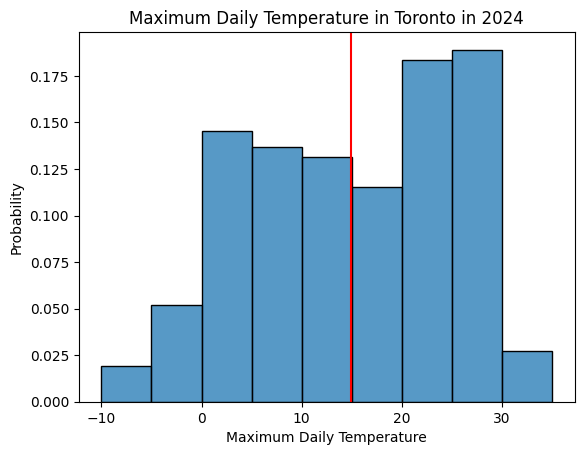

In [69]:
sns.histplot(max_temps, stat="probability", bins = range(-10, 40, 5)).axvline(x = mean_temp, color = "red")

plt.xlabel("Maximum Daily Temperature")

plt.ylabel("Probability")

plt.title("Maximum Daily Temperature in Toronto in 2024")

## Measures of Dispersion

In addition to understanding the most "central" or "typical" value, it is also important for us to know *how spread out* or *clustered together* the values are. 

For example, both of these distributions have the same mean, median, and mode, but they look really different!

![sd_example.png](sd_example.png)

### Standard Deviation

Standard deviation measures the "typical" distance between each individual value and the mean of the overall distribution.

This is accomplished by looking at the distance between *each* individual observation and the mean value. 


In this case, we know the mean daily maximum temperature is 14.9 degrees, so we can compare each day's maximum temperature to that annual mean:

In [60]:
difference_from_mean_temp = max_temps - mean_temp

difference_from_mean_temp

0     -16.303279
1     -14.303279
2     -12.503279
3     -14.103279
4     -15.603279
         ...    
361   -12.703279
362    -5.203279
363    -4.603279
364    -5.403279
365   -10.703279
Name: Max Temp (C), Length: 366, dtype: float64

If we graph these differences, we can see how far above/below the annual average each daily maximum temperature was located:

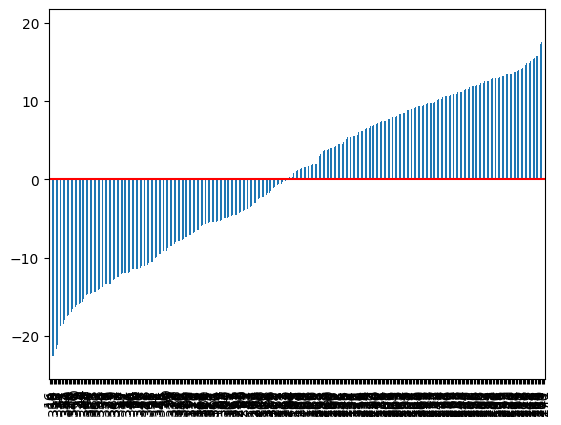

In [61]:
difference_from_mean_temp_sorted = difference_from_mean_temp.sort_values()

difference_from_mean_temp_sorted.plot.bar().axhline(y = 0, color = "red")

Standard deviation can be calculated using the following formula:

$$
\sigma = \sqrt{\frac{\Sigma(x_i - \mu)^2}{N}}
$$

Where:
- $\sigma$ = standard deviation
- $\Sigma$ = sum
- $(x_i - \mu)$ = difference between individual value and mean value (what we just calculated above)
- $N$ = number of observations

For our hypothetical distribution `[2, 4, 6, 8]` (where the mean is 5) the standard deviation would be:

$$
\sigma = \sqrt{\frac{\Sigma(x_i - \mu)^2}{N}} = \sqrt{\frac{(2 - 5)^2 + (4 - 5)^2 + (6 - 5)^2 + (8 - 5)^2}{4}}
$$

$$
= \sqrt{\frac{(-3)^2 + (-1)^2 + (1)^2 + (3)^2}{4}} = \sqrt{\frac{9 + 1 + 1 + 9}{4}}
$$

$$
= \sqrt{\frac{20}{4}} = \sqrt{5} ≈ 2.24
$$

Now, let's calculate this in Python!

$$
\sigma = \sqrt{\frac{\Sigma(x_i - \mu)^2}{N}}
$$

In [62]:
## Remove for lecture

numbers = pd.Series([2, 4, 6, 8])

mean = sum(numbers)/len(numbers)

difference = numbers - mean

squared_difference = difference**2

sum_squared_difference = sum(squared_difference)

standard_deviation = (sum_squared_difference / len(numbers)) ** 0.5

standard_deviation

## standard_deviation = ((sum((numbers - mean)**2))/len(numbers))**0.5 ## One-line solution


2.23606797749979

What are the mean and standard deviation if we have the following list of numbers instead: `[5, 5, 5, 5]`?

$$
\mu = \frac{\Sigma(x_i)}{N} = 
$$

$$
\sigma = \sqrt{\frac{\Sigma(x_i - \mu)^2}{N}} = 
$$

For daily maximum temperatures, we already have the difference between each individual value and the mean as `difference_from_mean_temp`. Now we just need to fill in the formula:

$$
\sigma = \sqrt{\frac{\Sigma(x_i - \mu)^2}{N}}
$$

In [63]:
difference_from_mean = max_temps - mean

difference_from_mean_squared = difference_from_mean**2

sum_difference_from_mean_squared = difference_from_mean_squared.sum()

N = len(max_temps)

standard_deviation = (sum_difference_from_mean_squared/N) ** 0.5

standard_deviation

np.float64(14.27120988893335)

## Other Statistical Distributions

There are *many* different types of statistical distributions, each representing a different real-world situation!

- **Bernoulli:** Single binary event (coin flip)

- **Binomial:** Multiple binary events (coin *flips*)

- **Uniform:** Event in which each outcome is equally likely (rolling a die)

- **Poisson:** Number of events that occur within a given time period (number of traffic accidents over a week)

- **Exponential:** Length of time *between* two events (length of time between traffic accidents)

- **Gaussian (Normal):** Outcomes of many random independent events

![distributions.png](distributions.png)

## Normal Distributions

One of the most important distributions in statistics is the "Gaussian" or **normal distribution** (sometimes described as a "bell curve")

![normal.png](normal.png)

In a perfectly normal distribution, the following will always be true:

- ~68.3% of possible outcomes are located within **one standard deviation** $(1\sigma)$ of the mean

- ~95.4% of possible outcomes are located within **two standard deviations** $(2\sigma)$ of the mean

- ~99.7% of possible outcomes are located within **three standard deviations** $(3\sigma)$ of the mean

For example, if the mean height is **175cm** (5'8") and the standard deviation is **10cm** (4"):

- 68.3% of people are between **165-185cm** (5'4"-6'0") tall

- 95.4% of people are between **155-195cm** (5'0"-6'4") tall

- 99.7% of people are between **145-205cm** (4'8"-6'8") tall


Normal distributions (with these exact characteristics) appear *all the time* in randomly-distributed data consisting of multiple independent events!

- This is due to a mathematical principle called the **Central Limit Theorem**. 

- When we have a large number of independent events with the same underlying probability, observations near the mean will happen more frequently, while values far above and below will be much less common.

- This week's lab will illustrate how this concept works using dice!


Real-life normally distributed variables include:

- Individuals' height and weight

- Test scores

- Years of education among working-age adults

- Daily temperatures

Next week, we will show how normal distributions can be used to extrapolate information about an entire population based on small samples!

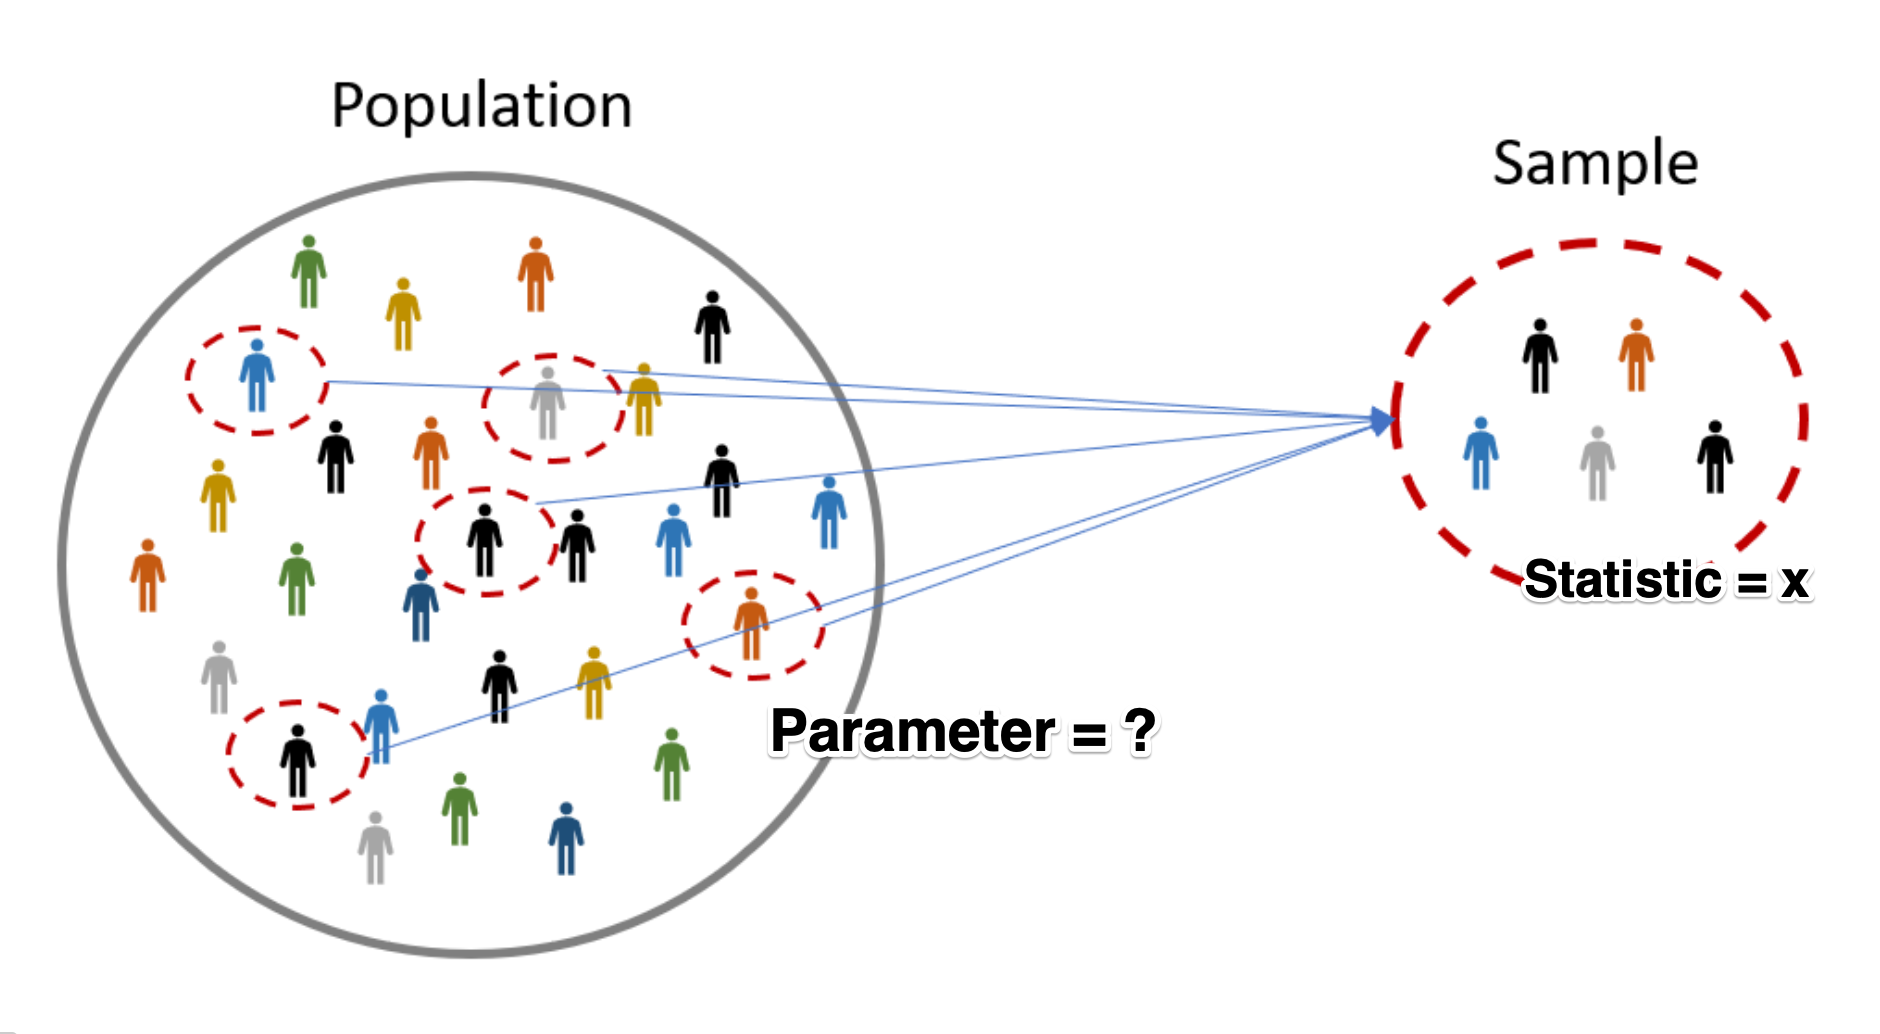